<a href="https://colab.research.google.com/github/ashwiniv07/Journal-paper--DDoS-GT-DL-/blob/main/Dataset5_TON_IoT_without_resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [ ]:
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Bidirectional, GRU, Dense,
    Dropout, Flatten, Attention, Permute, Multiply, Lambda, GlobalAveragePooling1D
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import shutil
from pathlib import Path
from scipy import stats
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Dataset Collection

In [ ]:
path = '/content/drive/MyDrive/project ashwini/TON_IoT'
destination_folder = '/content/Dataset'
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)
for filename in os.listdir(path):
    source_file = os.path.join(path, filename)
    destination_file = os.path.join(destination_folder, filename)
    if os.path.isfile(source_file):
        shutil.copy2(source_file, destination_file)
path = destination_folder
all_files = [os.path.join(dirname, filename) for dirname, _, filenames in os.walk(path) for filename in filenames]

## Step 2: Labelling the Dataset as Fraud-only, DDoS-only, Fraud-under-DDoS and Benign

In [ ]:
path = "/content/Dataset/TON_IoT.csv"
df = pd.read_csv(path)
drop_cols = ['dns_AA','dns_RD','dns_RA','dns_rejected','ssl_version','ssl_cipher','ssl_resumed','ssl_established','ssl_subject','ssl_issuer','http_trans_depth','http_method','http_uri','http_version','http_request_body_len','http_response_body_len','http_status_code','http_user_agent','http_orig_mime_types','http_resp_mime_types','weird_name','weird_addl','weird_notice']
df.drop(columns=drop_cols, inplace=True, errors='ignore')
df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
mapping = {
    'normal': 'Benign',
    'ddos': 'DDoS-only',
    'dos': 'DDoS-only',
    'backdoor': 'Fraud-only',
    'injection': 'Fraud-only',
    'mitm': 'Fraud-only',
    'password': 'Fraud-only',
    'ransomware': 'Fraud-only',
    'scanning': 'Fraud-only',
    'xss': 'Fraud-only'
}
df['Label'] = df['type'].map(mapping)
if 'src_ip' in df.columns:
    fraud_ips = set(df.loc[df['Label'] == 'Fraud-only', 'src_ip'])
    ddos_ips = set(df.loc[df['Label'] == 'DDoS-only', 'src_ip'])
    hybrid_ips = fraud_ips.intersection(ddos_ips)
    df.loc[df['src_ip'].isin(hybrid_ips), 'Label'] = 'Fraud-under-DDoS'
else:
    ddos_subset = df[df['Label'] == 'DDoS-only'].sample(frac=0.05, random_state=42)
    fraud_subset = df[df['Label'] == 'Fraud-only'].sample(frac=0.05, random_state=42)
    hybrid_indices = ddos_subset.sample(min(len(ddos_subset), len(fraud_subset))).index
    df.loc[hybrid_indices, 'Label'] = 'Fraud-under-DDoS'
output_path = "/content/Dataset/TON_IoT.csv"
df.to_csv(output_path, index=False)

## Step 3: Apply Preprocessing such as

### 1	Drop irrelevant columns	Reason: Remove non-useful or redundant information
### 2	Drop constant columns	Reason: Eliminate features with no variability
### 3	Encode labels	Reason: Convert categorical target to numeric
### 4	Handle missing values	Ensure no NaN values
### 5	Normalize features	Standardize numeric input features
### 6	Feature-label split	Prepare for training/evaluation

In [ ]:
df = pd.read_csv("/content/Dataset/TON_IoT.csv")
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
constant_cols = df.columns[df.nunique() <= 1]
df.drop(columns=constant_cols, inplace=True)
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Label_encoded')
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
X = df[numeric_cols].values
y = to_categorical(df['Label_encoded'].values)
X = X.reshape((X.shape[0], 1, X.shape[1]))

## Step 4: Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 4: Build Proposed CNN-BiGRU Model

In [ ]:
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=1)(x)
    x = Bidirectional(GRU(64, return_sequences=True))(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## Step 5: Train Proposed Model

In [ ]:
model = build_model(input_shape=X_train.shape[1:], num_classes=y_train.shape[1])
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    batch_size=8,
    verbose=1
)

Epoch 1/150
21105/21105 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - accuracy: 0.8499 - loss: 0.3276 - val_accuracy: 0.9204 - val_loss: 0.2311
Epoch 2/150
21105/21105 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - accuracy: 0.9128 - loss: 0.2195 - val_accuracy: 0.9260 - val_loss: 0.1840
Epoch 3/150
21105/21105 ━━━━━━━━━━━━━━━━━━━━ 69s 3ms/step - accuracy: 0.9336 - loss: 0.1821 - val_accuracy: 0.9461 - val_loss: 0.1514
Epoch 4/150
21105/21105 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - accuracy: 0.9393 - loss: 0.1677 - val_accuracy: 0.9422 - val_loss: 0.1628
Epoch 5/150
21105/21105 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - accuracy: 0.9457 - loss: 0.1545 - val_accuracy: 0.9554 - val_loss: 0.1234
Epoch 6/150
21105/21105 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - accuracy: 0.9493 - loss: 0.1419 - val_accuracy: 0.9556 - val_loss: 0.1183
Epoch 7/150
21105/21105 ━━━━━━━━━━━━━━━━━━━━ 63s 3ms/step - accuracy: 0.9514 - loss: 0.1350 - val_accuracy: 0.9536 - val_loss: 0.1267
Epoch 8/150
21105/21105 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - ac

## Step 6: Evaluate Proposed Model

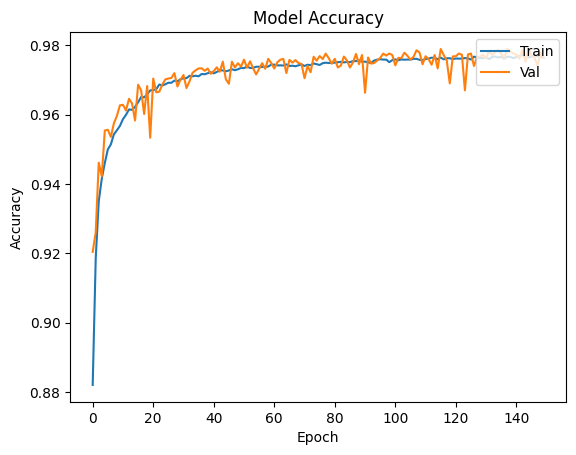

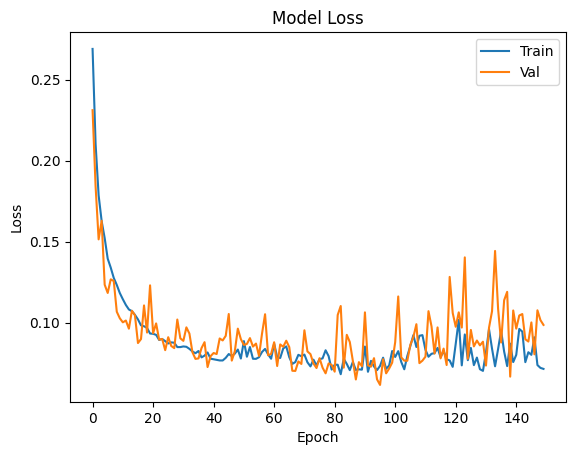

1320/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

 Classification Report:
                  precision    recall  f1-score   support

          Benign       1.00      1.00      1.00     10015
       DDoS-only       0.71      0.99      0.83       144
      Fraud-only       0.96      0.97      0.97     13624
Fraud-under-DDoS       0.98      0.97      0.97     18426

        accuracy                           0.98     42209
       macro avg       0.91      0.98      0.94     42209
    weighted avg       0.98      0.98      0.98     42209



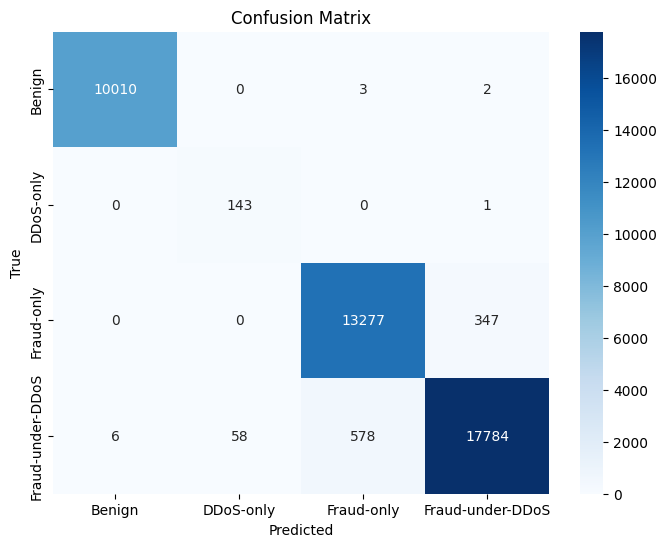

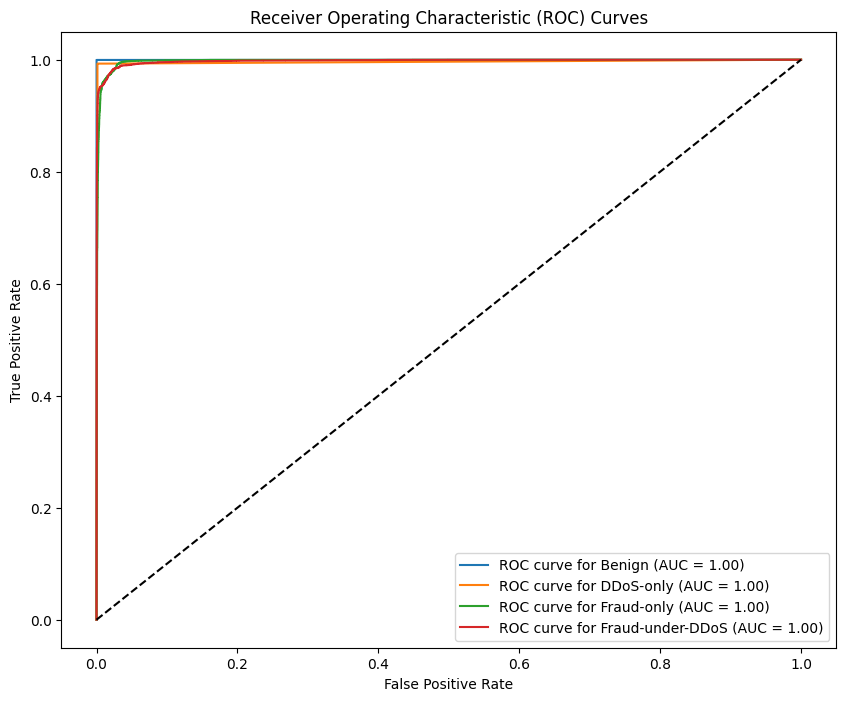


 AUC Score (OvR): 0.9978


In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
target_names = [str(c) for c in le.classes_]

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)


print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

plt.figure(figsize=(10, 8))
for i in range(len(target_names)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'ROC curve for {target_names[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()

try:
    auc_score = roc_auc_score(y_test, y_pred_probs, multi_class="ovr")
    print(f"\n AUC Score (OvR): {auc_score:.4f}")
except Exception as e:
    print(" Could not compute AUC:", e)


# Step 7: Implementation of Proposed CADE-GF

## Step 7 (a): Attacker Utility Function

In [ ]:
def attacker_utility(prob_fraud, threshold=0.5, cost_detected=1.0, reward_evade=5.0, cost_false_positive=0.5):
    if prob_fraud >= threshold:
        return -cost_detected * prob_fraud
    else:
        return reward_evade * (1 - prob_fraud) - cost_false_positive * prob_fraud

## Step 7 (b): Threshold Search Resolution Function

In [ ]:
def optimal_threshold(pred_probs, true_labels):
    thresholds = np.linspace(0.1, 0.9, 81)
    best_thresh = 0.5
    min_utility = float('inf')

    for t in thresholds:
        evasion_utilities = [
            attacker_utility(prob, threshold=t, cost_detected=2.0)
            for prob, true in zip(pred_probs, true_labels) if true != 0
        ]
        if evasion_utilities:
            avg_utility = np.mean(evasion_utilities)
            if avg_utility < min_utility:
                min_utility = avg_utility
                best_thresh = t
    return best_thresh

## Step 7 (c): Evasion Attack function

In [ ]:
def simulate_evasion(X, numeric_cols_indices, epsilon=0.1):
    X_evaded = X.copy()
    X_reshaped = X_evaded.reshape(X_evaded.shape[0], X_evaded.shape[2])
    noise = np.random.normal(0, epsilon, size=(X_reshaped.shape[0], len(numeric_cols_indices)))
    X_reshaped[:, numeric_cols_indices] += noise
    X_evaded = X_reshaped.reshape(X_evaded.shape)
    return X_evaded

## Step 8: Evalaution of CADE-GF
### Print Evalaution Metrics (AUC) Before/After

In [ ]:
feature_names = numeric_cols
continuous_traffic_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Bwd IAT Total',
    'Bwd IAT Mean', 'Bwd IAT Std', 'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Down/Up Ratio', 'Average Packet Size', 'Avg Fwd Segment Size',
    'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk',
    'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets',
    'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd',
    'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max',
    'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]
continuous_features_to_perturb = [f for f in continuous_traffic_features if f in feature_names]
continuous_feature_indices = [feature_names.index(f) for f in continuous_features_to_perturb if f in feature_names]
pred_probs = model.predict(X_test)
fraud_probs = pred_probs[:, 1]
y_true = np.argmax(y_test, axis=1)
opt_thresh = optimal_threshold(fraud_probs, y_true)
print(f"Optimal threshold: {opt_thresh:.3f}")
y_clean = (fraud_probs >= opt_thresh).astype(int)
X_evaded = simulate_evasion(X_test, continuous_feature_indices, epsilon=0.1)
fraud_probs_evaded = model.predict(X_evaded)[:, 1]
y_evaded = (fraud_probs_evaded >= opt_thresh).astype(int)
try:
    auc_clean = roc_auc_score(y_test, model.predict(X_test), multi_class='ovr')
    auc_evade = roc_auc_score(y_test, model.predict(X_evaded), multi_class='ovr')
    print(f"AUC (clean): {auc_clean:.4f}")
    print(f"AUC (evaded): {auc_evade:.4f}")
    print(f"AUC degradation: {auc_clean - auc_evade:.4f}")
    evasion_success = np.mean((y_clean == 1) & (y_evaded == 0))
    print(f"Evasion success rate: {evasion_success:.4f}")
except Exception as e:
    print(f"Evaluation error: {e}")

1320/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Optimal threshold: 0.100
1320/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 916us/step
1320/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step
1320/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 931us/step
AUC (clean): 0.9978
AUC (evaded): 0.9978
AUC degradation: 0.0000
Evasion success rate: 0.0000
